# Implementing the ZigZag Sampler

Basic notebook for implementing the ZigZag sampler as described in Annals paper by Bierkens, Fearnhead and Roberts.
`Joris Bierkens, Paul Fearnhead, Gareth Roberts "The Zig-Zag process and super-efficient sampling for Bayesian analysis of big data," The Annals of Statistics, Ann. Statist. 47(3), 1288-1320`

The ZigZag sampler is in the class of Piecewise Deterministic Markov Processes (PDMP), and relies on deterministically moving through the parameter space according to some system of ODEs, while changing directions at random time intervals. The stochasticity of when we change direction is driven by an inhomogenous Poisson Process, where the rate is tied to the target distribution of interest.


## Simulating from a Poisson Process
The elementary building block of the ZigZag Sampler is being able to simulate event times from an inhomogenous Poisson process. Here will look at how this can be done via Poisson thinning.

### The homogenous case
Simulating from a homogenous Poisson Process can be done with relative ease, utilizing the fact that the waiting times are exponentially distributed. That is if $N(t)$ denotes a Poisson Process with parameter $\lambda(t)=\lambda$, then the waiting time between events is distributed as $\text{Exp}(\lambda)$. Hence we can define arrival times by defining a sequence of \textit{iid} exponentially distributed random variables $\{X_t\}_{t=1}^{\infty}$, and define the arrival times as 
\begin{align}
T_1 &= X_1 \ \  \text{(first arrival)} \\
T_{n+1} &= X_{n+1} + T_n \ \ \text{(subsequent arrivals)}.
\end{align}
The Poisson Process is defined by the cumulative sum, $N(t)=\sum_{n=1}^{\infty}\mathbb{1}\left[T_n \leq t\right]$, while the Poisson point process is defined by the set of arrival times.

Going to create some basic function for plotting this in 1 dimension using matplotlib

In [ ]:
import numpy as np

k = 100 # Number of events

l = 10.0
l_vec = np.repeat(l,k)

Xt = np.random.exponential(l,k) # Sampling waiting times
Nt = np.cumsum(Xt) # Defining the Poisson point process

In [ ]:
from matplotlib import pyplot as plt
plt.plot(Nt, l_vec)

# Mark x locations on the x-axis with crosses
plt.scatter(Nt, [0]*len(Xt), color='red', marker='x', s=100)

# Add labels and legend
plt.show()

### The inhomogenous case
When the process is not homogenous, it is more difficult to simulate from the process. Say we have a more complex rate function, e.g. simulated from a Gaussian Process

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

lengthscale = 1
amplitude = 4.0

k = 100

# Define input locations (e.g., a 1D input space)
x = np.linspace(0, 10, k).reshape(-1, 1)

# Set up the GP with an RBF kernel
kernel = ConstantKernel(constant_value=amplitude, constant_value_bounds="fixed") * RBF(length_scale=lengthscale)
gp = GaussianProcessRegressor(kernel=kernel,random_state=None)

# Sample from the GP prior (without fitting to any data)
n_samples = 1
samples = gp.sample_y(x, n_samples,random_state=None)

rate = samples + 4

# Plot the samples
plt.plot(x, rate)
plt.ylim(0,15)

What would a realisation of a Poisson process with the rate defined as above look like?

We make use of Poisson Thinning to answer this question.

Poisson thinning means simulating first from a homogenous Poisson process, with a rate that upper bounds our true rate.
$\lambda_* \geq \lambda(t)$. Then delete the $i$-th event time with probability $1-\frac{\lambda(t)}{\lambda_*}$, independently for all $i$ time points. The resulting collection of event times is then a sample from the Poisson point process. To implement this, we use Algorithm 1 from Lewis and Shedler (1979)

In [ ]:
# Bounded lambda
l_star = np.max(rate)
T = np.max(x)
# Sampling waiting times
t = 0
Xt = []
while t <= T:
    u1 = np.random.uniform()
    t = t - 1.0/l_star * np.log(u1) # This is just sampling the homogenous process
    u2 = np.random.uniform() # Now we accept / reject this based on how the rate looks at this time point
    # Interpolate the rate to get at this exact time point
    lambda_time = np.interp(t, x.flatten(), rate.flatten())
    if u2 <= lambda_time/l_star:
        Xt.append(t)

Xt = np.array(Xt)

In [ ]:
# Plot the samples
plt.plot(x, rate)
plt.scatter(Xt, [0]*len(Xt), color='red', marker='x', s=100)

Okay, so now we know at least how to implement and simulate from an inhomogenous Poisson Process.

## Moving on to the ZigZag

Now interest is on exploring some target distribution $\pi(x)$ -- the typical case is when $x \in \mathbb{R}^d$ is some set of parameters, and $\pi(x)$ denotes the posterior distribution given some likelihood and a prior. The ZigZag sampler is a continuous time stochastic process whose trajectories lie in the space $\mathbb{R}^d \times \{-1,1\}^d$. The extra dimensions comes from equipping each *position* in the space with a corresponding *velocity*. We denote the position of our parameters by $\Xi(t) \in \mathbb{R}^d$ and the velocities by $\Theta(t)\in\{-1,1\}^d$, and denoted jointly by $(\Xi(t),\Theta(t))_{t > 0}$. The system moves linearly according to $\frac{d}{dt}\Xi(t)=\Theta(t)$, while at random time points a single component of $\Theta(t)$ flips sign. The $i$-th component flips according to the event of a inhomogenous Poisson process with rate $\lambda_i(\Xi(t),\Theta(t))$.

From an initial state $(T^0,\Xi^0,\Theta^0)=(0,\xi,\theta)$, the trajectories are constructed by
* For $k=1,2,\ldots$
    * Let $\xi^k(t):=\Xi^{k-1} + \Theta^{k-1}t,  \ t \geq 0$
    * For $i=1,\ldots,d$, let $\tau_i^{k}$ be distributed according to
       \begin{align}
      P(\tau_i^k \geq t) = \exp\left(-\int_0^t \lambda_i(\xi^k(s),\Theta^{k-1}) \text{d}s \right)
      \end{align}
    * Let $i_0 := \text{arg min}_{i\in\{1,\ldots,d\}} \tau_i^k$ and let $T^k:=T^{k-1}+\tau_{i_0}^k$
    * Let $\Xi^k:=\xi^k(T^k)$
    * Let
      \begin{align}
      \Theta^k(i) = \begin{cases}
      \Theta^{k-1}(i) & \text{if} \ i \neq i_0 \\
      -\Theta^{k-1}(i) & \text{if} \ i = i_0 \\
      \end{cases}
      \end{align}

The rate of the Poisson process driving the switching times can be related to the target distribution of interest. Notably, assuming the target distribution can be written as 
\begin{align}
\pi(\xi) = \frac{1}{Z}\exp\left(-\Psi(\xi)\right),
\end{align}
then the rates become $\lambda_i(\xi,\theta)=(\theta_i\partial_i\Psi(\xi))^+ + \gamma_i(\xi,\theta)$, where $\gamma_i(\xi,\theta)\geq 0$ controls some behaviour of the dynamics, e.g. a higher value corresponds to more frequent changes in velocity, and potentially slower mixing times. 

Now, to get this to work in practice, I need a few ingredients, and the flow is as follows

1. Compute the gradient of $\Psi(\xi)$, which in turn defines the event rate.
2. Find a bound on the event rate, for Poisson thinning
3. Draw the event times
4. Follow through the algorithm

### Simulating from a 2D Gaussian 

The first example I'll attempt is simply simulating from a target distribution that is the 2D Gaussian, e.g. target distribution is
\begin{align}
\pi(\xi) = \frac{1}{2\pi}\exp\left(-\frac{1}{2}(\xi_1^2+\xi_2^2)\right),
\end{align}
which makes $\Psi(\xi)=\frac{1}{2}(\xi_1^2+\xi_2^2)$

I could derive the gradient here by hand, but to make the method more general, I'll use autodiff via NumPyro.


In [ ]:
import jax.numpy as jnp
from jax import grad

def nll_2dgaussian(xi_1, xi_2):
    # Negative log-likelihood of the target density
    return 0.5 * (xi_1**2 + xi_2**2)

# Define a function to calculate the gradient of the NLL with respect to x and y
nll_gradient = grad(nll_2dgaussian, argnums=(0, 1))

# Print a little test
xi_1 = 4.0
xi_2 = 5.0
grad_xi_1, grad_xi_2 = nll_gradient(xi_1,xi_2)
print(f"Gradient at (xi_1, x_2) = ({xi_1}, {xi_2}): ∇x = {grad_xi_1}, ∇y = {grad_xi_2}")

We also need some other functions here giving both the rate at some time t, and the bound at some time t. 

**Note 12.11.24:** My very crude idea of bounding the rate with a scalar fails very spectacularly. I think we need something a bit more clever.

Since these examples are fairly easy, we can derive a bound by hand.

First note that the derivative of $\Psi(\xi)$ is simply $\partial_i \Psi(\xi):=\frac{\partial \Psi(\xi)}{\xi_i}=\xi_i$ and hence the rate takes the simple form $\lambda_i(\xi,\theta)=(\theta_i\xi_i)^+ + \gamma$

Following the definition of the event rate at time $t$ (having moved for a time t in direction $\Theta$ as
\begin{align}
m_i(t) &= \max\{0,\theta_i^{k-1}(\xi_i^{k-1}+\theta_i^{k-1}t)\} + \gamma \\
 &= \max\{0,\theta_i^{k-1}\xi_i^{k-1} + \underbrace{(\theta_i^{k-1})^2}_{=1}t  \} + \gamma \\
 &= \max\{0,\theta_i^{k-1}\xi_i^{k-1} + t \} + \gamma
\end{align}

A natural looking bound $M_i(t) \geq m_i(t)$ is 
\begin{align}
M(t) = \underbrace{\vert \theta_i^{k-1}\xi_i^{k-1} \vert + \gamma}_{a} + \underbrace{ 1 \cdot t}_{bt},
\end{align}
which has a known primitive since $\Lambda(t)=\int_0^t a + bt \ \text{d}s=at + \frac{bt^2}{2}$.

Now, to sample from this (bounded-rate) inhomogenous Poisson process we will use the method due to Çinlar (1975):
1. Initialise $s \leftarrow 0 $
2. Draw $u \sim \mathcal{U}(0,1)$
3. Set $s \leftarrow s - \log u$
4. Deliver $t \leftarrow \inf\{v : \Lambda(v) > s\}$
5. Go to step 2

For the very specific primitive we have for the multivariate normal, finding the infimum can be done explicitly as it is simply the root of the quadratic form $\frac{b}{2}t^2+at-s = 0$, with solution $t=\frac{\sqrt{a^2+2bs}-a}{b}$

Now, we can start building the sampler

In [ ]:
%time

k = 10000 # Number of iterations

Position = np.zeros((k+1,2)) # Storing positions
Velocity = np.zeros((k+1,2)) # Storing Velocities
Time = np.zeros((k)) # Storing time
TimeDim = np.zeros((2)) # Sampling time via Cinlar for each parameter dimension
gamma = 0.01

# Initialise these
xi = (1,-1)
theta = (-1.0,1.0)
time = 0
Position[0,:] = xi
Velocity[0,:] = theta
Time[0] = time

# Starting the sampler
for n in range(1,k):
    pos = Position[(n-1),:] # Current position
    vel = Velocity[(n-1),:] # Current velocity
    ###### Simulate the Poisson Process for the times
    u1 = np.random.random(2) # Step 2 of Çinlar
    TimeDim = - np.log(u1) # Step 3 of Çinlar
    a = np.abs(vel*pos)+gamma
    b = 1
    TimeDim = (np.sqrt(a**2+2*b*TimeDim)-a)/b # Step 4 of Çinlar

    # Find the minimum time passed
    i0 = np.argmin(TimeDim)
    tau = TimeDim[i0]

    # Setting new values for positions and parameters
    Position[n,:] = pos + vel*tau
    Time[n] = Time[n-1] + tau

    

    # Accept/reject step for flipping velocity
    u2 = np.random.random()
    rate = np.maximum(0,vel*(pos + vel*tau)) + gamma
    bounded_rate = a + b*tau
    acc = (u2 <= rate[i0]/bounded_rate[i0])
    if acc:
        vel[i0] *= -1
    # Setting new value for velocity
    Velocity[n,:] = vel

    

    
    
    

In [ ]:
Time

In [ ]:
plt.plot(Position[20:120,0], Position[20:120,1])

So now we have a skeleton in place consisting of points where the algorithm rejected the point and changed direction. Every single point inbetween these skeleton points are samples from the target distribution (and notably the skeleton points themselves are not).

To get an actual sample out from this, we usually want to do some thinning of each trajectory. 

Let's do the basic thing first where we take the midpoint of each line segment

**NOTE** This is actually biased, and instead we should sample e.g. equally spaced in time.

In [ ]:
Position.shape

In [ ]:
from scipy.stats import gaussian_kde

samples = np.zeros(((k-1),2))

for n in range(1,k):
    samples[(n-1),:] = (Position[n,:] + Position[(n-1),:])/2.0


plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, label="Samples",s=0.5)

# Perform kernel density estimation for the contour plot
kde = gaussian_kde(samples.T)
x, y = np.mgrid[-3:3:100j, -3:3:100j]  # Adjust the range as needed
positions = np.vstack([x.ravel(), y.ravel()])
density = kde(positions).reshape(x.shape)

# Plot contour lines of the density estimate
plt.contour(x, y, density, colors='blue', linewidths=0.5)

### Bayesian Linear regression

Now wanting to implement a simple linear regression, actually sampling from the posterior distribution. The target will still be multivariate normal, but slightly more complicated now.

We consider standard Bayesian linear regression, with known noise variance. That is,
\begin{align}
\mathbf{y} &= X\boldsymbol{\beta} + \boldsymbol{\epsilon} \\
\boldsymbol{\beta} &\sim \mathcal{N}(0,\alpha^2I) \\
\boldsymbol{\epsilon} &\sim \mathcal{N}(0,\sigma^2I),
\end{align}
where $\alpha$ and $\sigma$ are known and fixed hyperparameters. We could consider something more complex for the regression coefficients, something like a scale-mixture. But this will do for now.

Under this model, the posterior distribution can be derived by hand.

\begin{align}
\boldsymbol{\beta} \vert \mathbf{y} &\sim \mathcal{N}(\mu_n,\Sigma_n), \\
\mu_n &= \left(\frac{I}{\alpha^2}+\frac{X^TX}{\sigma^2}\right)^{-1}\frac{X^T\mathbf{y}}{\sigma^2} \\
\Sigma_n &= \left(\frac{I}{\alpha^2}+\frac{X^TX}{\sigma^2}\right)
\end{align}

So the modifications we need to make to the above example is simply the target being slightly more complex in terms of the mean and variance of the multivariate normal.

In particular, we need to look at the rate, and the bound of the rate.

The target now looks like $\pi(\boldsymbol{\beta})=(2\pi)^{-d/2}\vert\Sigma_n\vert^{-1/2}\exp\left(-\frac{1}{2}(\boldsymbol{\beta}-\mu_n)^T\Sigma_n^{-1}(\boldsymbol{\beta}-\mu_n)\right)$, and the negative log likelihood, ignoring terms that don't contain parameters becomes
\begin{align}
\Psi(\boldsymbol{\beta})=\frac{1}{2}(\boldsymbol{\beta}-\mu_n)^T\Sigma_n^{-1}(\boldsymbol{\beta}-\mu_n),
\end{align}

differentiating this wrt. $\beta_i$ yields
\begin{align}
\partial_i \Psi(\boldsymbol{\beta}) :=\frac{\partial}{\partial\beta_i} \Psi(\boldsymbol{\beta}) = \sum_{j=1}^d \Sigma_{n,ij}^{-1}(\beta_j-\mu_{n,j}),
\end{align}
note that since $\Sigma_n$ doesn't depend on any parameters that change during sampling, we can compute this inverse once and store it. The rate now becomes 

\begin{align}
\lambda(\beta_i,\theta_i) = (0,\theta_i\sum_{j=1}^d\Sigma_{n,ij}^{-1}(\beta_j-\mu_{n,j}))^{+} + \gamma_i,
\end{align}
and following the event rate at time $t$ (having moved for a while), we compute 
\begin{align}
m_i(t) &= \max\left\{0,\theta_i^{k-1}\sum_{j=1}^d\Sigma_{n,ij}^{-1}(\beta_j^{k-1} + \theta_j^{k-1} t-\mu_{n,j})\right\} + \gamma_i.
\end{align}
Looking at this, the most natural bound would be something like:
\begin{align}
M_i(t)&=\sum_{j=1}^d \vert \Sigma_{n,ij}^{-1} \vert \left(\vert \beta_j-\mu_{n,j} \vert+t\right) + \gamma_i\\
&= \underbrace{\sum_{j=1}^d \vert \Sigma_{n,ij}^{-1} \vert\vert \beta_j-\mu_{n,j} \vert + \gamma_i}_{a} + \underbrace{\sum_{j=1}^d\vert \Sigma_{n,ij}^{-1}}_{b} \vert t,
\end{align}
and hence this is of the same form as before.

In [ ]:
import numpy as np

In [ ]:
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 10
alpha = 2.0
sigma = 1.0
X = np.random.randn(n, d)
beta = np.random.normal(0,alpha,size=d)
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

# And define some of the matrices and vectors I need
Sigma = ((np.eye(d)/(alpha**2)) + (X.T @ X)/(sigma**2))
mu = np.linalg.inv(Sigma) @ (X.T @ y)/(sigma**2)

In [ ]:
np.linalg.inv(Sigma)[0,0]

Now we can build the sampler, code is quite similar to before

In [ ]:
%time

k = 100000 # Number of iterations

Position = np.zeros((k,d))
Velocity = np.zeros((k,d))
Time = np.zeros((k))
TimeDim = np.zeros((d)) # This will now depend on the size of the active set
gamma = 0.01 # Can be made specific to each covariate

# Initialise these
beta_init = np.random.normal(0,alpha,size=d) # Initialize from prior
theta = -1.0+2*np.random.randint(2,size=d) # Random elements in {-1,1}
time = 0
Position[0,:] = beta_init
Velocity[0,:] = theta
Time[0] = time


# Starting the sampler
for n in range(1,k):
    # This first part goes as normal
    pos = Position[(n-1),:] # Current position
    vel = Velocity[(n-1),:] # Current velocity
    ###### Simulate the Poisson Process for the times
    u1 = np.random.random(d) # Step 2 of Çinlar
    TimeDim = - np.log(u1) # Step 3 of Çinlar
    a = np.abs(Sigma)@np.abs(pos-mu) + gamma
    b = np.sum(np.abs(Sigma),axis=1)
    TimeDim = (np.sqrt(a**2+2*b*TimeDim)-a)/b # Step 4 of Çinlar

    # Find the minimum time passed
    i0 = np.argmin(TimeDim)
    tau = TimeDim[i0]

    

    # Setting new values for positions and parameters
    Position[n,:] = pos + vel*tau
    Time[n] = Time[n-1] + tau

    

    # Accept/reject step for flipping velocity
    u2 = np.random.random()
    # Compute rate
    rate = np.float32(np.maximum(0,vel[i0]*(Sigma[i0,:] @ (pos-mu+vel*tau))) + gamma)
    # Compute bounded rate
    a = np.abs(Sigma[i0,:])@np.abs(pos-mu)+gamma
    b = np.sum(np.abs(Sigma[i0,:]))
    bounded_rate = np.float32(a + b*tau)
    p = rate/bounded_rate
    acc = (u2 <= p)
    if acc:
        vel[i0] *= -1.0
    # Setting new value for velocity
    Velocity[n,:] = vel

    

    
    
    

In [ ]:
plt.plot(Position[:,0], Position[:,1])

In [ ]:
samples = np.zeros(((k-1),d))

for n in range(1,k):
    samples[(n-1),:] = (Position[n,:] + Position[(n-1),:])/2.0



In [ ]:
param = 5
plt.plot(samples[:,param])
plt.axhline(y=mu[param],color="red")

In [ ]:
beta[0]

In [ ]:
plt.scatter(samples[:,0],samples[:,5],s=0.1,marker=".")

## The Sticky Zig-Zag
This implements the sticky-zig zag as proposed in:
`Bierkens, J., Grazzi, S., Meulen, F. V. D., & Schauer, M. (2023). Sticky PDMP samplers for sparse and local inference problems. Statistics and Computing, 33(1), 8.`

The sticky Zig-Zag was developed primarily for Bayesian inference, when the prior takes a spike-and-slab form, i.e.
\begin{align}
\mu_0(\text{d}\xi)=\prod_{i=1}^d w_i\pi_i(\xi_i)\text{d}\xi+(1-w_i)\delta_0(\text{d}\xi_i),
\end{align}
where $\delta_0$ denotes the Dirac delta at zero (the spike), and $\pi(\cdot)$ is some known density (the slab), e.g. a Gaussian. 

Combined with a log-likelihood $\ell(\xi)$ the sticky Zig-Zag was developed to sample from target distributions of the form
\begin{align}
\mu(\text{d}\xi)=C_{\mu}\exp\left\{-\Psi(\xi)\right\}\prod_{i=1}^d\left(\text{d}\xi_i + \frac{1}{\kappa_i}\delta_0(\text{d}\xi_i)\right), 
\end{align}
where $\Psi(\xi)=C-\ell(\xi)-\sum_{i=1}^d\log\pi_i(\xi_i)$.

This looks slightly strange, but note that the posterior distribution over $\xi$ can indeed be written in this way, with $\kappa_i=\frac{w_i}{1-w_i}\pi_i(0)$

\begin{align}
\mu(\text{d}\xi) &= C_{\mu}\exp\left\{-\Psi(\xi)\right\}\prod_{i=1}^d\left(\text{d}\xi_i + \frac{1}{\kappa_i}\delta_0(\text{d}\xi_i)\right) \\
&\propto \exp\left\{C+\ell(\xi)+\sum_{i=1}^d\log\pi_i(\xi_i)\right\}\prod_{i=1}^d\left(\text{d}\xi_i + \frac{1}{\kappa_i}\delta_0(\text{d}\xi_i)\right) \\
&\propto L(\xi)\left(\prod_{i=1}^d \pi_i(\xi_i)\text{d}\xi_i + \frac{\pi_i(\xi_i)}{\kappa_i}\delta_0(\text{d}\xi_i)\right) \\
&=L(\xi)\prod_{i=1}^d \frac{1}{w_i}\left( w_i\pi_i(\xi_i)\text{d}\xi_i + \cancel{\frac{\pi_i(\xi_i)}{\pi_i(0)}}(1-w_i)\delta_0(\text{d}\xi_i)\right) \\
&\propto L(\xi)\mu_0(\text{d}\xi),
\end{align}
where $L(\xi)$ denotes the likelihood.

The way the dynamics of the Zig-Zag sampler needs to be changed to have the above as target density is by introducing a notion of *freezing* and *thawing*. Moving through the target space, the sampler detects if any coordinate hits a "frozen boundary"
\begin{align}
\mathfrak{F}_i := \{(\xi,\theta) \in \mathbb{R}^d\times\{-1,1\}^d : \xi_i=0^-, \theta_i > 0 \text{ or } \xi_i=0^+, \theta_i < 0\},
\end{align}
where $0^-$ and $0^+$ denotes if $\xi_i$ is coming into zero from above or below. Once a coordinate hits a frozen boundary, it will "stick" to the boundary, setting $(\xi_i,\theta_i)=(0,0)$ for a time $f_i \sim \text{Exp}(\kappa_i)$. Once this time is up, the coordinate will start moving again in the same direction, with the same velocity as before.

Analogous to the weights in the spike-and-slab, we can interpret $t^{(i)}_a/t^{(i)}_f$, where $t^{(i)}_a$ denotes the time the $i$-th coordinate was actively moving and $t^{(i)}_f$ the time it was frozen, as the inclusion probability of the coordinate. 

In terms of the implementation, the only thing we need to adopt is some mechanism for which coordinates are frozen, and which are moving freely, as well as another clock giving the freezing time. We will denote these two sets *active* and *frozen*, $\mathcal{A}=\{i : \theta_i \neq 0\}$, $\mathcal{F}=\{i:\theta_i=0\}$. A nice feature of the sticky Zig-Zag is that we only need to care about event rates for the active set. If most of our coordinates are frozen, i.e. $\vert\mathcal{F}\vert > \vert\mathcal{A}\vert$, this can yield computational speedups that makes the Zig-Zag sampler more applicable in high-dimensional settings.

**Update 20.11.24:** Okay, I don't think this is fully true, and the computation of our rates and everything will still depend on all positions. There are however some speedsups possible, according to remark D.1 in the Sticky Zig-Zag paper.

### Implementation 
And so, the only think I need to do to implement this in my algorithm is
1. Compute event times
2. Find $\tau^*$ the minimum event time
3. If ($\tau^*< \text{ thawing time}$ for **all** $i\in\mathcal{F}$) **and** ($\tau^*< \text{ freezing time}$ for **all** $i\in\mathcal{A}$) **Basic Zig-Zag, no freezing or thawing to worry about.**
    * Update skeleton
    * Time is $\tau^*$
4. *or*, if ($\tau^*> \text{ time to hit }\mathfrak{F}_i$ for some $i\in\mathcal{A}$) **One component freezes**
    * Update skeleton with $(\xi_i,\theta_i)=(0,0)$
    * Update freezing clock, and set component as inactive
    * Time is whatever time it took to hit the boundary.
5. *or*, if ($\tau^* > \text{ thawing time}$ for **some** $i\in\mathcal{F}$) **One component thaws**
    * Set $\theta_i^{k}=\theta_i^{k-1}$ (or rather the velocity it had before freezing)
    * Update skeleton
    * Time is thawing time for $i$-th component

Now, can think of a way to optimize this a bit. First of all, $\{1,\ldots,n\}=\mathcal{A}\cup\mathcal{F}$, and so we can define a single vector, e.g. $A\in\{0,1\}^d$, indicating which coefficients are in the active set, and thus also which are in the frozen set. When we then go to update the skeleton, it should be sufficient to do `pos + A * vel * tau`, leading to only active components moving.

In addition to worrying about "thawing time", we need to think about time to hit a freezing boundary. In the 3rd step of the algorithm, it might be the case that we hit a freezing boundary before the time $\tau^*$ has passed. And so we need to also keep track of how long it is until components in the active set hit a boundary. 

Given a velocity $\Theta$ and a position $\Xi$, we need to work out when each component will hit their corresponding $\mathfrak{F}_i$.
There are only two cases when this can happen
1. If $\xi_k < 0$ and $\theta_k > 0$
2. If $\xi_k > 0$ and $\theta_k < 0$

Succinctly, these can be summarised as the condition $\theta_k\xi_k < 0$, in which case the time at which this happens is $t=-\xi_k/\theta_k$. For those components where this is not true, they will never freeze while moving in the current direction. The code below implements this.

In [ ]:
d = 10
xi = np.random.normal(0,10,size=d) # Initialize from prior
theta = -1.0+2*np.random.randint(2,size=d) # Random elements in {-1,1}
valid = (theta*xi < 0) # Find those that the condition is true for 
freeze = (-xi/theta) # Generating freezing-times
freeze[~valid] = np.inf # Replace those that will never freeze with inf

In [ ]:
# To make the final sampler more readable, let's wrap this in a function
def freezing_time(xi,theta):
    valid = (theta*xi < 0) # Find those that the condition is true for
    freeze = np.full((theta.size),np.inf,float)
    freeze[valid] = (-xi[valid]/theta[valid]) # Replace those that will never freeze with inf
    return freeze

And so I need 3 clocks, i) the basic ZigZag one calculated only for the active set $\mathcal{A}$, 2) the freezing clock calculated only for the active set $\mathcal{A}$, and 3) a thawing clock calculated for the frozen set $\mathcal{F}$.

### Bayesian linear regression with a spike-and-slab prior

Following the similar setup from before, where 
\begin{align}
\mathbf{y} &= X\boldsymbol{\beta} + \boldsymbol{\epsilon} \\
\boldsymbol{\epsilon} &\sim \mathcal{N}(0,\sigma^2I),
\end{align}
but instead of sampling $\boldsymbol{\beta}$ directly from something like a normal, we are going to partition the coefficient vector into an active and non-active component, where the non-active components are simply zero, $\boldsymbol{\beta}=[\boldsymbol{\beta}_a,0,\ldots,0]$. We will assume of our $d$ components, only $d_0<d$ are active, and drawn from a multivariate normal distribution with prior $\mathcal{N}(0,\alpha^2I)$.

And we can simulate this dataset

In [ ]:
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 20
d0 = 5 # Active components
alpha = 2
sigma = 1.5
X = np.random.randn(n, d)
beta_a = np.random.normal(0,alpha,size=d0)
beta = np.concat((beta_a,np.zeros(d-d0)))
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

In [ ]:
print(beta)

But now, we need to think about the modelling setup. 

Our likelihood is the standard one from previously, $L(\boldsymbol{\beta})=\mathcal{N}(X\boldsymbol{\beta},\sigma^2I)$, but our prior now takes the form
\begin{align}
\beta_i \sim w_i\pi_i(\beta_i) + (1-w_i)\delta_0(\beta_i), \ i=1,\ldots,d
\end{align}
where we will take the weight $w_i$ as a given hyperparameter, and the slab $\pi_i(\beta_i)=\mathcal{N}(0,\alpha^2)$ for all $i=1,\ldots,d$.

Now, we need to look at the target, which we previously defined for the Sticky Zig-Zag as 
\begin{align}
\Psi(\boldsymbol{\beta})&=C-\ell(\boldsymbol{\beta})-\sum_{i=1}^d\log\pi_i(\beta_i) \\
&=C-\log\left(L(\boldsymbol{\beta})\prod_{i=1}^d\pi_i(\beta_i))\right) \\
&=C'-\log\left(\pi(\boldsymbol{\beta}\vert\mathbf{y})\right),
\end{align}
where $\pi(\boldsymbol{\beta})$ is the standard posterior distribution derived before! And so
\begin{align}
\Psi(\boldsymbol{\beta})=\frac{1}{2}(\boldsymbol{\beta}-\mu_n)^T\Sigma_n^{-1}(\boldsymbol{\beta}-\mu_n),
\end{align}
where 

\begin{align}
\boldsymbol{\beta} \vert \mathbf{y} &\sim \mathcal{N}(\mu_n,\Sigma_n), \\
\mu_n &= \left(\frac{I}{\alpha^2}+\frac{X^TX}{\sigma^2}\right)^{-1}\frac{X^T\mathbf{y}}{\sigma^2} \\
\Sigma_n &= \left(\frac{I}{\alpha^2}+\frac{X^TX}{\sigma^2}\right)
\end{align}

and

differentiating this wrt. $\beta_i$ yields
\begin{align}
\partial_i \Psi(\boldsymbol{\beta}) :=\frac{\partial}{\partial\beta_i} \Psi(\boldsymbol{\beta}) = \sum_{j=1}^d \Sigma_{n,ij}^{-1}(\beta_j-\mu_{n,j}).
\end{align}

Thus we can reuse the bounds and everything from before.

In [ ]:
# Here we compute the mean and covariance we need for the calculations
Sigma = ((np.eye(d)/(alpha**2)) + (X.T @ X)/(sigma**2))
mu = np.linalg.inv(Sigma) @ (X.T @ y)/(sigma**2)
# And we need the kappa parameters for freezing times
weights = np.full((d),d0/(d-d0),float)
dens_at_zero = 1 / (np.sqrt(2 * np.pi) * alpha)
kappa = weights/(1-weights)*dens_at_zero

In [ ]:
mu

In [ ]:
kappa

#### Code to implement

In [ ]:
%%time

k = 10000 # Number of iterations

Position = np.zeros((k,d))
Velocity = np.zeros((k,d))
Time = np.zeros((k))
#TimeDim = np.zeros((d)) # This will now depend on the size of the active set
gamma = 0.01 # Can be made specific to each covariate, controls an overall rate of rejections (if this is too big we move slowly)

# Initialise these
beta_init = np.random.normal(0,alpha,size=d) # Initialize from N(0,1)
theta = -1.0+2*np.random.randint(2,size=d) # Random elements in {-1,1}
time = 0
Position[0,:] = mu # Note that I actually initialise from known posterior mean
Velocity[0,:] = theta
Time[0] = time

# Define my new clocks
thawing = np.full((d),np.inf,float) # These are frozen coefficients counting down initialise these at inf 
active = np.full((d),True,bool) # In the beginning, all components are active
vel_at_freeze = np.zeros((d)) # something to store the velocity a component had when it froze


# Starting the sampler
for n in range(1,k):
    # We first just look at our active set and find out how large it is
    n_active = sum(active).item()
    n_frozen = sum(~active).item()
    
    # This first part goes as normal
    pos = Position[(n-1),:] # Current position
    vel = Velocity[(n-1),:] # Current velocity

    # Now we also update our freezing-times given our current position and velocity
    freezing = freezing_time(pos,vel)
    
    ###### Simulate the Poisson Process for the times
    u1 = np.random.random(d) # Step 2 of Çinlar
    TimeDim = - np.log(u1) # Step 3 of Çinlar
    a = np.abs(Sigma)@np.abs(pos-mu) + gamma
    b = np.sum(np.abs(Sigma),axis=1)
    TimeDim = (np.sqrt(a**2+2*b*TimeDim)-a)/b # Step 4 of Çinlar

    # Find the minimum time passed
    i0 = np.argmin(TimeDim)
    tau_star = TimeDim[i0] # This is the suggested time now

    # Now we need to define if we will see a freezing or thawing event
    thawing_event = False
    freezing_event = False
    # Let's check if we get a thawing event first
    if (n_frozen > 0): # We must have some frozen components
        if (tau_star > thawing[~active]).any(): # the current suggested time step needs to be larger than a thawing time for any component
            thawing_event = True
            tau_star = thawing[~active].min() # We overwrite the current tau_star with the time of the thawing event
    # Let's check if we get a freezing event
    if (n_active >0): # We must have some active components
        if (tau_star > freezing[active]).any(): # the current suggested time step needs to be larger than a freezing time for any component
            freezing_event = True # We will freeze a component
            thawing_event = False # We will no longer thaw a component
            tau_star = freezing[active].min() # Overwrite suggested time since we get freezing event

    # Now making some different choices depending on these things
    # If neither freezing or thawing event, regular ZigZag
    if not (thawing_event or freezing_event):
        # Setting new values for positions and parameters
        Position[n,:] = pos + vel*tau_star
        Time[n] = Time[n-1] + tau_star

        # Accept/reject step for flipping velocity
        u2 = np.random.random()
        # Compute rate
        rate = np.float32(np.maximum(0,vel[i0]*(Sigma[i0,:] @ (pos-mu+vel*tau_star))) + gamma)
        # Compute bounded rate
        a = np.abs(Sigma[i0,:])@np.abs(pos-mu)+gamma
        b = np.sum(np.abs(Sigma[i0,:]))
        bounded_rate = np.float32(a + b*tau_star)
        p = rate/bounded_rate
        acc = (u2 <= p)
        if acc:
            vel[i0] *= -1.0
        # Setting new value for velocity
        Velocity[n,:] = vel
        
    # If there is a freezing event
    if freezing_event:
        i_freeze = np.argmin(freezing) # which component is freezing?
        print("Freezing the ", i_freeze, " component!")
        Position[n,:] = pos + vel*tau_star
        Time[n] = Time[n-1] + tau_star
        Velocity[n,:] = vel
        Position[n,i_freeze] = 0.0 # set position for frozen component
        Velocity[n,i_freeze] = 0.0 # set velocity for frozen component
        vel_at_freeze[i_freeze] = vel[i_freeze] # store the velocity it had before it froze
        active[i_freeze] = False # set component as inactive
        thawing[i_freeze] = np.random.exponential(kappa[i_freeze]) # How long will it stay frozen?
    
    # If there is a thawing event
    if thawing_event:
        i_thaw = np.argmin(thawing)
        print("Thawing the ", i_thaw, " component!")
        Position[n,:] = pos + vel*tau_star
        Time[n] = Time[n-1] + tau_star
        Velocity[n,:] = vel
        Velocity[n,i_freeze] = vel_at_freeze[i_thaw] # set velocity for the thawed component
        active[i_thaw] = True # set component as active
        thawing[i_thaw] = np.inf # this is no longer frozen


    # Finally we update our clocks
    thawing = thawing - tau_star
   
        

        

    
    

    

    

    
    


In [ ]:
i1 = 0
i2 = 10
plt.plot(Position[:,i1], Position[:,i2])
plt.axvline(beta[i1],color="red",alpha=0.3)
plt.axhline(beta[i2],color="red",alpha=0.3)
plt.xlabel("beta_0")
plt.ylabel("beta_10")
num_arrows = 4
for i in range(0,k,int(k/num_arrows)-1):
    print(i)
    plt.arrow(Position[i,i1],Position[i,i2],Position[i+1,i1]-Position[i,i1],Position[i+1,i2]-Position[i,i2], shape='full', lw=0, length_includes_head=True, head_width=.004)

In [ ]:
samples = np.zeros(((k-1),d))

for n in range(1,k):
    samples[(n-1),:] = (Position[n,:] + Position[(n-1),:])/2.0



In [ ]:
param = 1
burnin = 0
plt.plot(samples[int(burnin*k):,param])
plt.axhline(y=beta[param],color="red",alpha=0.4)

In [ ]:
plt.scatter(samples[int(0.9*k):,0],samples[int(0.9*k):,16],s=0.1,marker=".")

In [ ]:
# We can also look at inclusion probabilities
# The proper way to do this would be to look at the time spend at zero for each coefficient, but as an estimate
# we can look at the number of times the samples were exactly zero
probabilities = 1-(samples==0).mean(axis=0)

In [ ]:
probabilities

## Automatic Zig-Zag

Now, having implemented a basic version of the Zig-Zag, and the Sticky version, allowing for spike-and-slab style prior distribution, it is time to tackle the perhaps more difficult implementation of the Automatic Zig-Zag as proposed in:
`Corbella, A., Spencer, S. E., & Roberts, G. O. (2022). Automatic Zig-Zag sampling in practice. Statistics and Computing, 32(6), 107`.

The main idea here is to tackle the case where the rate cannot be easily bounded, and so sampling the inhomogenous Poisson process isn't easy. That is, the integral $\Lambda(t)=\int_0^t\lambda(\xi(s),\theta(s))\text{d}s$ is not easily computable, canonically in this setting because the rate depends on e.g. some black-box function we can only evaluate and compute gradients of, but cannot write down in analytic form. This could for example be in the setting there the target of interest is via a likelihood that is expensive to compute, or otherwise analytically intractable, e.g. a neural network.


The main idea is to use Poisson Thinning directly, but find local constant bounds over some interval $[0,t_{\text{max}}]$, i.e.
\begin{align}
\bar{\lambda}(t_{\max},\xi_i,\theta_i) = \max_{t\in[0,t_{\max}]} \{\lambda(\xi_i(t),\theta_i(t))\},
\end{align}
and these bounds are found adaptively having access only to the gradient of some black-box function $\Psi$, $\nabla \Psi$.

The way this is done in practice is using Automatic-Differentiation (AD) and Brent's method for optimization. This looks like it might be quite troublesome in high-dimensions, but in principle we only need to compute rejection times for the active components.

I think fundamentally, I don't need to deeply understand Brent's method, but in the paper they make some minor modification to Brent's which means that I probably need to understand it well enough to adapt some existing implementation. 

**NOTE** I think what they do in principle is being clever about when to not bother running Brent. Filippo will know more about this.

### Brent's optimisation method

Brent's method for optimization combines inverse parabolic interpolation with Golden Section search that inherits stability and convergence guarantees from the Golden Section and speed from inverse parabolic interpolation.

The objective is to minimize (or maximize) some function $f:\mathbb{R}\to\mathbb{R}$ ($-f$ for maximization), and is derivative/Hessian free, only relying on us being able to evaluate $f$ on some inputs $x$.

We will use the example function $f(x)=1 - 1.1x -0.2x^2 - 1x^3 - 0.2x^4$, here and try to maximize it on the interval $[-1.5,4.5]$ where we know a global maximum exists.

In [ ]:
def f(x):
    return -(1 - 1.1*x -0.2*x**2 + 1*x**3 - 0.2*x**4) # negative because we are maximizing

In [ ]:
x_seq = np.linspace(-1.5,4.5,100)
y_seq = f(x_seq)

In [ ]:
plt.plot(x_seq,-y_seq)

For the algorithm, we need to set some tolerances $\epsilon$, the aboslute precision for the x-value, and $\delta$, the relative precision (to prevent tiny steps near the actual solution). The algorithm also needs to kep track of some numbers.
* $[a,b]$ the end points of the interval
* $x$ current best estimate of minimum
* $w$ second best estimate of minimum (close to $x$)
* $v$ previous $w$, used for interpolation
* $f(x),f(w),f(v)$ the function values at these points.

For initilisation, we choose $x=w=v$ e.g. like $a+(b-a)/2$, and then we evaluate $f(a),f(x),f(b)$

In [ ]:
# Brent minimizer
a = -1.5
b = 4.5
tol = 1e-1
rel_tol = 1e-1
phi = (1+5**0.5)/2

x = w = v = a + (b-a)/2
f_x = f_w = f_v = f(x)

x_iters = []

maxiter = 100
# Now for the algorithm itself
iter = 0
while (np.abs(b-a) > tol + rel_tol*abs(x)):
    u = None
    if x != w and x != v  and w != v:
        numerator = (x-w)**2*(f_x-f_v) - (x-v)**2*(f_x-f_w)
        denominator = 2*((x-w)*(f_x-f_v) - (x-v)*(f_x-f_w))
        if denominator != 0:
            u = x - numerator / denominator
    if u is not None and a < u < b and abs(u-x) >= tol:
        # Use this interpolated u further
        pass
    else:
        # Golden section
        if x < (a+b)/2:
            u = x + (b - x) / phi
        else:
            u = x - (b - x) / phi
    # Evaluate f at u
    f_u = f(u)

    # Update the interval
    if f_u < f_x:
        # Better min found
        if u < x:
            b = x
        else:
            a = x
        v, w, x = w, x, u
        f_v, f_w, f_x = f_w, f_x, f_u
    else:
        # Interval reduction
        if u < x:
            a = u
        else:
            b = u
        if f_u <= f_w or w == x:
            v, w, = w, u
            f_v, f_w = f_w, f_u
        elif f_u <= f_v or v==x or v==w:
            v = u
            f_v = f_u

    x_iters.append(x)
    
    
    # Update iter
    iter += 1
    if iter > maxiter:
        break
print("Converged after: ",iter," iterations")

In [ ]:
plt.plot(x_seq,-y_seq)
plt.scatter(np.array(x_iters),-f(np.array(x_iters)),color="red")

Now, let's wrap this into a function to be used inside the Automatic Zig-Zag

In [1]:
def brent(f,a,b,tol=1e-5,rel_tol=1e-5):
    # Brent minimizer
    phi = (1+5**0.5)/2

    x = w = v = a + (b-a)/2
    f_x = f_w = f_v = f(x)

    #x_iters = []

    maxiter = 100
# Now for the algorithm itself
    iter = 0
    while (np.abs(b-a) > tol + rel_tol*abs(x)):
        u = None
        if x != w and x != v  and w != v:
            numerator = (x-w)**2*(f_x-f_v) - (x-v)**2*(f_x-f_w)
            denominator = 2*((x-w)*(f_x-f_v) - (x-v)*(f_x-f_w))
            if denominator != 0:
                u = x - numerator / denominator
        if u is not None and a < u < b and abs(u-x) >= tol:
            # Use this interpolated u further
            pass
        else:
            # Golden section
            if x < (a+b)/2:
                u = x + (b - x) / phi
            else:
                u = x - (b - x) / phi
        # Evaluate f at u
        f_u = f(u)
    
        # Update the interval
        if f_u < f_x:
            # Better min found
            if u < x:
                b = x
            else:
                a = x
            v, w, x = w, x, u
            f_v, f_w, f_x = f_w, f_x, f_u
        else:
            # Interval reduction
            if u < x:
                a = u
            else:
                b = u
            if f_u <= f_w or w == x:
                v, w, = w, u
                f_v, f_w = f_w, f_u
            elif f_u <= f_v or v==x or v==w:
                v = u
                f_v = f_u
        # Update list to get path
        #x_iters.append(x)
        
        
        # Update iter
        iter += 1
        if iter > maxiter:
            break
    #print("Converged after: ",iter," iterations")
    return x


In [ ]:
a = -1.5
b = 5.5
x_star = brent(f,a,b)
print(x_star)

### Linear regression again

Consider again the linear regression model
\begin{align}
\mathbf{y} &= X\boldsymbol{\beta} + \boldsymbol{\epsilon} \\
\boldsymbol{\beta} &\sim \mathcal{N}(0,\alpha^2I) \\
\boldsymbol{\epsilon} &\sim \mathcal{N}(0,\sigma^2I),
\end{align}

With analytical posterior
\begin{align}
\boldsymbol{\beta} \vert \mathbf{y} &\sim \mathcal{N}(\mu_n,\Sigma_n), \\
\mu_n &= \left(\frac{I}{\alpha^2}+\frac{X^TX}{\sigma^2}\right)^{-1}\frac{X^T\mathbf{y}}{\sigma^2} \\
\Sigma_n &= \left(\frac{I}{\alpha^2}+\frac{X^TX}{\sigma^2}\right)
\end{align}


In [ ]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 10
alpha = 2.0
sigma = 1.0
X = np.random.randn(n, d)
beta = np.random.normal(0,alpha,size=d)
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

# And define some of the matrices and vectors I need
Sigma = ((np.eye(d)/(alpha**2)) + (X.T @ X)/(sigma**2))
mu = np.linalg.inv(Sigma) @ (X.T @ y)/(sigma**2)

Now, instead of explicitly using the analytical posterior, will set it up as a general target distribution with JAX for this.

In [ ]:
import jax.numpy as jnp
from jax import grad, jit

def target(beta,mu,Sigma_inv):
    a = beta-mu
    b = jnp.matmul(Sigma_inv,a)
    c = jnp.matmul(jnp.transpose(a),b)
    return 0.5*c

d_target = jit(grad(target,argnums=(0)))


Now, instead of dealing with d Poisson processes, we will use the fact that if $X_1,\ldots,X_d \sim \text{Exp}(\lambda_i)$ for $i=1,\ldots,d$ independently. Then $\min \{X_1,\ldots,X_d\}\sim \text{Exp}(\sum_{i=1}^d\lambda_i)$, and we need to find a bound for this in the interval $[0,t_{\text{max}}]$. Now, if there is an event in this interval, the component that switches is given by $i \sim \text{MultiNomial}(\lambda_1,\ldots,\lambda_d) $.

**NOTE** This is part of the suggested speedups in the Sticky Zig Zag as well. Notably if a lot of parameters are frozen, we can sample thawing times using a $\min$ argument. The rates might possible also be simpler, with each frozen parameter essentially having the same rate, so no need to query all.

In [ ]:
# Wrap this now into a function that we will maximize using Brent's method
from functools import partial

# First properly define the rate as a function of time
def rate(time,pos0,vel,gamma,mu=mu,Sigma=Sigma):
    pos = pos0 + vel*time
    rate = np.sum(np.maximum(0,vel*d_target(pos,mu,Sigma)) + gamma)
    return -rate # For minimization


And now we can go directly to the implementation. It will look very similar to before, but now we only update skeleton points if there is an event in the small interval of interest. The general flow for finding $\tau$ will be like this:
* Compute $\bar{\lambda}$ over the interval $[0,t_{\text{max}}]$
* Sample an event time $\tau^*$
* Thin according to $\lambda(\Xi(\tau^*),\Theta(\tau^*))/\bar{\lambda}$
* If $\tau^*$ survives thinning, then check if $\tau^*\in[0,t_{\text{max}}]$
    * if **yes**, do regular zigzag update
    * if **no** move on

#### Implementation

In [ ]:
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 5000
d = 10
alpha = 2.0
sigma = 0.5
X = np.random.randn(n, d)
beta = np.random.normal(0,alpha,size=d)
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

# And define some of the matrices and vectors I need
Sigma = ((1.0/(alpha**2)) + (X.T @ X)/(sigma**2))
mu = np.linalg.inv(Sigma) @ (X.T @ y)/(sigma**2)

In [ ]:
k = 5000 # Number of iterations (desired skeleton points)
t_max = 0.01 # The time window to bound the rate inside

# Set up containers
Position = np.zeros((k,d))
Velocity = np.zeros((k,d))
Time = np.zeros((k))
gamma = 0.01 # Can be made specific to each covariate

# Initialise these
beta_init = np.random.normal(0,alpha,size=d) # Initialize from prior
theta = -1.0+2*np.random.randint(2,size=d) # Random elements in {-1,1}
time = 0
Position[0,:] = beta_init
Velocity[0,:] = theta
Time[0] = time

In [ ]:
# Wrap this now into a function that we will maximize using Brent's method
from functools import partial

# First properly define the rate as a function of time
def rate(time,pos0,vel,gamma,mu=mu,Sigma=Sigma):
    pos = pos0 + vel*time
    rate = np.sum(np.maximum(0,vel*d_target(pos,mu,Sigma)) + gamma)
    return -rate # For minimization


In [ ]:
%%time

iter = 1
time_passed = 0.0
while iter < k: # While loop now until we reach the desired number of events
    # This first part goes as normal
    vel = Velocity[(iter-1),:] # Current velocity
    pos = Position[(iter-1),:] + vel*time_passed # Current position
    # Then we define a partial function of this for the current values of position and velocity to be used in the optimization
    rate_time = partial(rate,pos0=pos,vel=vel,mu=mu,Sigma=Sigma,gamma=gamma)
    
    # Optimize to find bound on rate
    x_star = brent(rate_time,0,t_max) # Find time point at which rate is maximum
    lambda_max = -rate_time(x_star) # Calculate the rate at this point
    # And then we can compute an event time
    tau_star = np.random.exponential(1/lambda_max,1)
    # And now we do thinning to see if this time survives
    u = np.random.random()
    lambda_star = -rate_time(tau_star)
    p = lambda_star/lambda_max
    #print("Probability of accepted event: ", p)
    acc = (u <= p)
    if acc and (tau_star < t_max):
        #print("event!")
        # Which component is flipping velocity?
        rates = np.maximum(0,vel*d_target(pos+vel*tau_star,mu,Sigma)) + gamma
        rates = np.asarray(rates).astype('float64')
        rates = rates / np.sum(rates)
        
        # Setting new values for positions and parameters
        Position[iter,:] = pos + vel*tau_star
        Time[iter] = Time[iter-1] + time_passed + tau_star.item()
        # Velocity now flips!
        i0 = np.argmax(np.random.multinomial(1,rates)).item()
        vel[i0] *= -1.0 # Velocity flip!
        Velocity[iter,:] = vel
        # Increasing iteration and setting the local clock to zero again
        iter += 1
        time_passed = 0.0
    else:
        time_passed += t_max
        

In [ ]:
import matplotlib.pyplot as plt

beg = 45
end = beg+10

i1 = 0
i2 = 6
plt.plot(Position[2500:,i1], Position[2500:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))

covariance = np.linalg.inv(Sigma)
i1_min = mu[i1]-1.96*np.sqrt(covariance[i1,i1])
i1_max = mu[i1]+1.96*np.sqrt(covariance[i1,i1])
i2_min = mu[i2]-1.96*np.sqrt(covariance[i2,i2])
i2_max = mu[i2]+1.96*np.sqrt(covariance[i2,i2])


x_grid, y_grid = np.linspace(i1_min, i1_max, 100), np.linspace(i2_min, i2_max, 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid = np.dstack((X_grid, Y_grid))  # Combine x and y into coordinate pairs

from scipy.stats import multivariate_normal
rv = multivariate_normal(mu[[i1,i2]], covariance[[i1,i2],:][:,[i1,i2]])
Z = rv.pdf(grid)

min_val, max_val = Z.min(), Z.max()
contour_levels = np.linspace(min_val, max_val, 8)  # Adjust the number of levels

#density = kde(positions).reshape(x.shape)

# Plot contour lines of the density estimate
plt.contour(X_grid, Y_grid, Z,levels=contour_levels, colors='red', linewidths=0.5)
#plt.contour(x, y, density, colors='blue', linewidths=0.5)


## Sticky Automatic Zig-Zag

We can also think about combining these things, in order to use spike-and-slab style priors on models that are not nice and conjugate, that instead involve just some complex target distribution. This was done e.g. in `Hardcastle, Luke, Samuel Livingstone, and Gianluca Baio. "Averaging polyhazard models using Piecewise deterministic Monte Carlo with applications to data with long-term survivors." arXiv preprint arXiv:2406.14182 (2024)` to enable trans-dimensional MCMC in a polyhazard model.

Fundamentally, the only thing that needs to change compared to the Automatic Zig-Zag from above is the introduction of freezing and thawing clocks, and some extra checks

### Bayesian linear regression with a spike-and-slab prior

We are still in the setting now of Bayesian linear regression with a spike-and-slab prior. Hence 
\begin{align}
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}, \ \ \boldsymbol{\epsilon} \sim \mathcal{N}(0,\sigma^2\mathbf{I}),
\end{align}
and $\boldsymbol{\beta} = [\boldsymbol{\beta}_a,0,\ldots,0]$, where $d_0=\vert \boldsymbol{\beta}_a \vert < \vert \boldsymbol{\beta} \vert=d$. 

Active components are sampled as $\boldsymbol{\beta}_a \sim \mathcal{N}(0,\alpha^2 \mathbf{I})$.

We place spike-and-slab priors on each beta coefficient, 
\begin{align}
\beta_i &\sim w_i\pi_i(\beta_i) + (1-w_i)\delta_0(\beta), \ i=1,\ldots,d, \\
\pi_i(\beta_i) &= \mathcal{N}(0,\alpha^2), \ i= 1,\ldots,d.
\end{align}

Now the target is written 
\begin{align}
\Psi(\boldsymbol{\beta}) &= -\log \mathcal{N}(\mathbf{y} \vert \mathbf{X}\boldsymbol{\beta},\sigma^2\mathbf{I})- \log \mathcal{N}(\boldsymbol{\beta}\vert\mathbf{0},\alpha^2\mathbf{I}) \\
 &= C  + \frac{1}{2\sigma^2}(\mathbf{y}-\mathbf{X}\boldsymbol{\beta})^T(\mathbf{y}-\mathbf{X}\boldsymbol{\beta}) + \frac{1}{2\alpha^2}\boldsymbol{\beta}^T\boldsymbol{\beta}
\end{align}

In [2]:
import numpy as np
import jax.numpy as jnp
from jax import grad, jit
from functools import partial
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

In [127]:
# I need to sample some true coefficients, a design matrix and some actual data
n = 100
d = 200
d0 = 5 # Active components
alpha = 4.0
sigma = 0.1
X = np.random.randn(n, d)
beta_a = np.random.normal(0,alpha,size=d0)
beta = np.concat((beta_a,np.zeros(d-d0)))
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon

# And we need the kappa parameters for freezing times
weights = np.full((d),d0/(d-d0),float)
dens_at_zero = 1 / (np.sqrt(2 * np.pi) * alpha)
kappa = weights/(1-weights)*dens_at_zero

In [128]:
print(beta)

[ 0.65167591 -5.39809755  8.83787778  1.66254375  3.58585992  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         

In [129]:
# Here comes the target distribution
def target(beta,y,X,sigma,alpha):
    a = (y-jnp.matmul(X,beta))
    likelihood = 1.0/(2.0*sigma**2)*jnp.dot(a,a)
    prior = 1.0/(2.0*alpha**2)*jnp.dot(beta,beta)
    return likelihood + prior

d_target = jit(grad(target,argnums=(0)))

And we can also compare this to the true value of the derivatives
\begin{align}
\partial_i \Psi(\boldsymbol{\beta}) :=\frac{\partial}{\partial\beta_i} \Psi(\boldsymbol{\beta}) = \sum_{j=1}^d \Sigma_{n,ij}^{-1}(\beta_j-\mu_{n,j}).
\end{align}

In [130]:
Sigma = np.eye(d)/(alpha**2) + (X.T @ X)/(sigma**2)
mu = np.linalg.solve(Sigma, (X.T @ y)/(sigma**2))

# Autodiff
autodiff = (d_target(beta,y,X,sigma,alpha))
# Manual
manual = (Sigma @ (beta - mu))
np.column_stack([autodiff,manual])

array([[ 8.83399277e+01,  8.83402790e+01],
       [-9.15378647e+01, -9.15376670e+01],
       [-1.00992195e+02, -1.00998219e+02],
       [-4.94000549e+01, -4.94014272e+01],
       [-1.50980499e+02, -1.50982691e+02],
       [-1.20964355e+01, -1.20969087e+01],
       [-2.58080254e+01, -2.58075367e+01],
       [ 3.66326866e+01,  3.66325851e+01],
       [-5.27282143e+01, -5.27299541e+01],
       [-3.69353638e+01, -3.69349051e+01],
       [ 9.95735855e+01,  9.95731065e+01],
       [ 3.81480217e+01,  3.81496162e+01],
       [-1.50989361e+01, -1.50968537e+01],
       [ 5.54674983e-01,  5.54331731e-01],
       [-1.04402298e+02, -1.04402190e+02],
       [ 1.39885950e+01,  1.39886026e+01],
       [ 7.41602707e+01,  7.41604369e+01],
       [-2.13565125e+02, -2.13565792e+02],
       [ 2.97203140e+01,  2.97197794e+01],
       [ 3.19732571e+01,  3.19736685e+01],
       [-6.15934105e+01, -6.15932895e+01],
       [-5.42404175e+01, -5.42404285e+01],
       [-8.00119705e+01, -8.00121033e+01],
       [-1.

In [131]:
# Wrap this now into a function that we will maximize using Brent's method
# First properly define the rate as a function of time
def rate(time,pos0,vel,gamma,y=y,X=X,sigma=sigma,alpha=alpha):
    pos = pos0 + vel*time
    rate = np.sum(np.maximum(0,vel*d_target(pos,y,X,sigma,alpha)) + gamma)
    return -rate # For minimization

We also have this function to calculate the freezing time for our parameters given the current trajectory

In [132]:
# To make the final sampler more readable, let's wrap this in a function
def freezing_time(xi,theta):
    valid = (theta*xi < 0) # Find those that the condition is true for
    freeze = np.full((theta.size),np.inf,float)
    freeze[valid] = (-xi[valid]/theta[valid]) # Replace those that will never freeze with inf
    return freeze

#### Sampler

In [ ]:
%%time

k = 500000 # Number of iterations (desired skeleton points)
t_max = 0.0001 # The time window to bound the rate inside

# Set up containers
Position = np.zeros((k,d))
Velocity = np.zeros((k,d))
Time = np.zeros((k))
gamma = 0.01 # Can be made specific to each covariate

# Initialise these
beta_init = np.random.normal(0,1,size=d) # Initialize near zero
theta = -1.0+2*np.random.randint(2,size=d) # Random elements in {-1,1}
time = 0
max_time = 1000.0
Position[0,:] = beta_init
Velocity[0,:] = theta
Time[0] = time

# Define my new clocks
thawing = np.full((d),np.inf,float) # These are frozen coefficients counting down initialise these at inf 
active = np.full((d),True,bool) # In the beginning, all components are active
vel_at_freeze = np.zeros((d)) # something to store the velocity a component had when it froze

# Keeping track of iterations and time passed
iter = 1
time_passed = 0.0

# Set up a progress bar
pbar = tqdm(total=k, desc="Zig-Zag time", unit="iter")

while iter < k: # While loop now until we reach the desired number of events
#while time < max_time: # While loop now until we reach the desired number of events
    
    # We first just look at our active set and find out how large it is
    n_active = sum(active).item()
    n_frozen = sum(~active).item()

    
    # This first part goes as normal
    vel = Velocity[(iter-1),:] # Current velocity
    pos = Position[(iter-1),:] + vel*time_passed # Current position
    # Then we define a partial function of this for the current values of position and velocity to be used in the optimization
    rate_time = partial(rate,pos0=pos,vel=vel,gamma=gamma,y=y,X=X,sigma=sigma,alpha=alpha)
    # Now we also update our freezing-times given our current position and velocity
    freezing = freezing_time(pos,vel)
    
    # Optimize to find bound on rate
    x_star = brent(rate_time,0,t_max) # Find time point at which rate is maximum
    lambda_max = -rate_time(x_star) # Calculate the rate at this point
    # And then we can compute an event time
    tau_star = np.random.exponential(1/lambda_max,1)
    # And now we do thinning to see if this time survives
    u = np.random.random()
    lambda_star = -rate_time(tau_star)
    p = lambda_star/lambda_max
    acc = (u <= p)
    # Okay, so if we have an accepted time, we need to handle three seperate cases
    #   i) Regular rejection step
    #  ii) Freezing event
    # iii) Thawing event
    # Set up flags for these 
    regular_event = False
    thawing_event = False
    freezing_event = False
    # Is there a regular event
    if acc and (tau_star < t_max):
        regular_event = True
    # Is there a thawing event before this?
    if (n_frozen > 0): # We must have some frozen components
        if ((min(tau_star,t_max) > thawing[~active]).any()): # the current suggested time step needs to be larger than a thawing time for any component, but smaller than the curent window
            thawing_event = True # A component will thaw
            regular_event = False # There will not be a regular event
            tau_star = thawing[~active].min() # We overwrite the current tau_star with the time of the thawing event
    # Let's check if we get a freezing event
    if (n_active >0): # We must have some active components
        if ((min(tau_star,t_max) > freezing[active]).any()): # the current suggested time step needs to be larger than a freezing time for any component, but smaller than the curent window
            freezing_event = True # We will freeze a component
            thawing_event = False # We will no longer thaw a component
            regular_event = False # There will not be a regular event
            tau_star = freezing[active].min() # Overwrite suggested time since we get freezing event
    
    # Now we handle the events 
    # If regular event:
    if regular_event:
        # Which component is flipping velocity?
        rates = np.maximum(0,vel*d_target(pos+vel*tau_star,y,X,sigma,alpha)) + gamma
        rates = np.asarray(rates).astype('float64')
        rates = rates / np.sum(rates)
        
        # Setting new values for positions and parameters
        Position[iter,:] = pos + vel*tau_star
        Time[iter] = Time[iter-1] + time_passed + tau_star.item()
        # Velocity now flips!
        i0 = np.argmax(np.random.multinomial(1,rates)).item()
        vel[i0] *= -1.0 # Velocity flip!
        Velocity[iter,:] = vel
        
        pbar.update(1)
        # Increasing iteration and setting the local clock to zero again
        iter += 1
        time_passed = 0.0
        # Finally we update our clocks and print time
        thawing = thawing - tau_star
        
    # If there is a freezing event
    if freezing_event:
        i_freeze = np.argmin(freezing) # which component is freezing?
        print("Freezing the ", i_freeze, " component!")
        Position[iter,:] = pos + vel*tau_star
        Time[iter] = Time[iter-1] + tau_star
        Velocity[iter,:] = vel
        Position[iter,i_freeze] = 0.0 # set position for frozen component
        Velocity[iter,i_freeze] = 0.0 # set velocity for frozen component
        vel_at_freeze[i_freeze] = vel[i_freeze] # store the velocity it had before it froze
        active[i_freeze] = False # set component as inactive
        thawing[i_freeze] = np.random.exponential(kappa[i_freeze]) # How long will it stay frozen?
        
        pbar.update(1)
        # Increasing iteration and setting the local clock to zero again
        iter += 1
        time_passed = 0.0
        # Finally we update our clocks
        thawing = thawing - tau_star
  
    
    # If there is a thawing event
    if thawing_event:
        i_thaw = np.argmin(thawing)
        print("Thawing the ", i_thaw, " component!")
        Position[iter,:] = pos + vel*tau_star
        Time[iter] = Time[iter-1] + tau_star
        Velocity[iter,:] = vel
        Velocity[iter,i_freeze] = vel_at_freeze[i_thaw] # set velocity for the thawed component
        active[i_thaw] = True # set component as active
        thawing[i_thaw] = np.inf # this is no longer frozen
        
        pbar.update(1)
        # Increasing iteration and setting the local clock to zero again
        iter += 1
        time_passed = 0.0
        # Finally we update our clocks and update pbar
        thawing = thawing - tau_star
        

    # Finally, if nothing happens we increase the time passed by the tmax 
    if not (regular_event or freezing_event or thawing_event):
        time_passed += t_max

    time = Time[iter]   
    # I'll also print iter
    #print(iter)

Zig-Zag time:   0%|          | 0/500000 [00:00<?, ?iter/s]

Freezing the  117  component!
Freezing the  88  component!
Freezing the  174  component!
Freezing the  87  component!
Freezing the  198  component!
Freezing the  107  component!
Freezing the  35  component!
Freezing the  124  component!
Freezing the  29  component!
Freezing the  125  component!
Thawing the  87  component!
Freezing the  84  component!
Freezing the  81  component!
Thawing the  29  component!
Freezing the  196  component!
Thawing the  124  component!
Thawing the  81  component!
Thawing the  117  component!
Thawing the  107  component!
Freezing the  38  component!
Thawing the  84  component!
Freezing the  46  component!
Freezing the  100  component!
Freezing the  92  component!
Freezing the  194  component!
Thawing the  88  component!
Freezing the  21  component!
Thawing the  100  component!
Freezing the  63  component!
Freezing the  113  component!
Thawing the  92  component!
Freezing the  11  component!
Freezing the  134  component!
Thawing the  113  component!
Thawing t

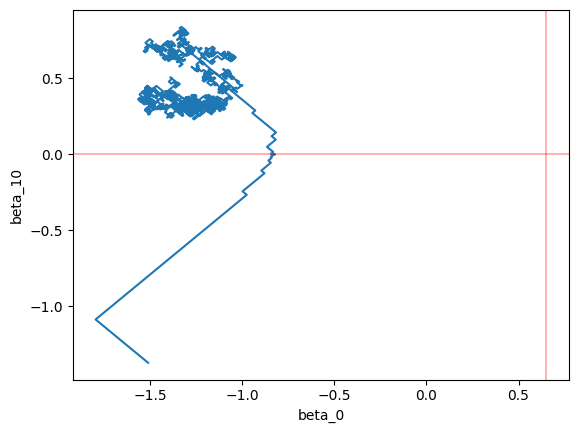

In [155]:
i1 = 0
i2 = 7
burnin = 0
plt.plot(Position[burnin:,i1], Position[burnin:,i2])
#plt.xlim(-2, 2)
#plt.ylim(-2, 2)
plt.axvline(beta[i1],color="red",alpha=0.3)
plt.axhline(beta[i2],color="red",alpha=0.3)
plt.xlabel("beta_0")
plt.ylabel("beta_10")
num_arrows = 4
#for i in range(0,k,int(k/num_arrows)-1):
#    print(i)
#    plt.arrow(Position[i,i1],Position[i,i2],Position[i+1,i1]-Position[i,i1],Position[i+1,i2]-Position[i,i2], shape='full', lw=0, length_includes_head=True, head_width=.004)

In [138]:
burnin = 30000
samples = np.zeros(((k-burnin-1),d))

for n in range(1,k-burnin):
    samples[n-1,:] = (Position[burnin + n - 1,:] + Position[(burnin + n -1 ),:])/2.0



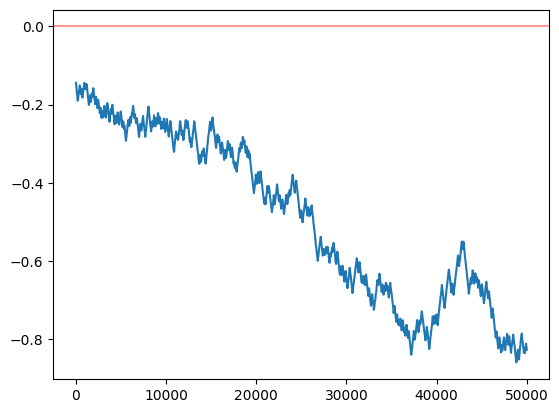

In [139]:
param = 11
plt.plot(samples[:,param])
plt.axhline(y=beta[param],color="red",alpha=0.4)

In [103]:
# We can also look at inclusion probabilities
# The proper way to do this would be to look at the time spend at zero for each coefficient, but as an estimate
# we can look at the number of times the samples were exactly zero
probabilities = 1-(samples==0).mean(axis=0)
probabilities

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.        , 0.        , 0.        , 0.        , 0.94609461,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [159]:
Time[k-1].item()

20.29755396521876